## FIELD ML - v2

Main target: `BT_Vel_stage1` 

1. `dropna()` replaces `fillna(mean)` — NaN in targets = filtered pings, must be dropped
2. OLS + Ridge + Lasso added as linear baselines 
3. Filtering sensitivity added 
4. BS_rel as additional feature 

**Models:** OLS + Ridge + Lasso + RF + GB + XGB + LGBM + CatBoost + Stacking
**Validation:** 5-fold stratified CV + 80/20 split


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import shap

# ── Load dataset ──────────────────────────────────────────────────────────────
DATA_PATH = (
    r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive'
    r'\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx'
)
df = pd.read_excel(DATA_PATH)
print(f'Loaded: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

# ── Feature columns (7 core features) ─────────────────────────
FEATURES = ['Depth','Vel_StdDev','Correlation','Mean_Speed',
            'SNR','Vel_Expected_StdDev','Bin_Distance']

# ── Model zoo (ML models + linear baselines) ───────────────────────────────
def get_models():
    return {
        'OLS':             LinearRegression(),
        'Ridge':           Ridge(alpha=1.0),
        'Lasso':           Lasso(alpha=0.001, max_iter=5000),
        'Random Forest':   RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'XGBoost':         XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
        'LightGBM':        LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
        'CatBoost':        CatBoostRegressor(iterations=100, random_state=42, verbose=0),
        'Stacking Regressor': StackingRegressor(
            estimators=[
                ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
                ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
            ],
            final_estimator=Ridge()),
    }

def run_cv(X, y, n_splits=5):
    """
    CORRECT stratified CV.
    X, y must already have NaN DROPPED — no filling.
    """
    bins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
    y_binned = bins.fit_transform(y.values.reshape(-1,1)).ravel().astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    for name, model in get_models().items():
        print(f'  CV: {name}...')
        pipe = make_pipeline(StandardScaler(), model)
        r2s, mses = [], []
        for tr, te in skf.split(X, y_binned):
            pipe.fit(X.iloc[tr], y.iloc[tr])
            yp = pipe.predict(X.iloc[te])
            r2s.append(r2_score(y.iloc[te], yp))
            mses.append(mean_squared_error(y.iloc[te], yp))
        results.append({'Model': name,
                        'Mean R²': round(np.mean(r2s),4),
                        'Std R²':  round(np.std(r2s),4),
                        'Mean MSE': round(np.mean(mses),6),
                        'Std MSE':  round(np.std(mses),6)})
    return pd.DataFrame(results).sort_values('Mean R²', ascending=False)

def run_split(X, y, test_size=0.2):
    """
    CORRECT 80/20 split.
    X, y must already have NaN DROPPED — no filling.
    """
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42)
    sc = StandardScaler().fit(X_tr)
    X_tr_s, X_te_s = sc.transform(X_tr), sc.transform(X_te)
    results = []
    trained_models = {}
    for name, model in get_models().items():
        print(f'  Split: {name}...')
        model.fit(X_tr_s, y_tr)
        yp = model.predict(X_te_s)
        results.append({'Model': name,
                        'R²':    round(r2_score(y_te, yp),4),
                        'MSE':   round(mean_squared_error(y_te, yp),6)})
        trained_models[name] = (model, X_tr_s, X_te_s, y_tr, y_te)
    df_res = pd.DataFrame(results).sort_values('R²', ascending=False)
    return df_res, trained_models

print('Setup complete. Models: OLS, Ridge, Lasso, RF, GB, XGB, LGBM, CatBoost, Stacking')


Loaded: (10869, 24)
Columns: ['Transect', 'ensemble_idx', 'BT_Vel_pre', 'BT_Vel_stage0', 'BT_Vel_stage1', 'BT_Vel_stage2', 'BT_Vel_stage3', 'BT_Vel_stage4', 'Depth', 'Mean_Speed', 'Vel_StdDev', 'Correlation', 'Vel_Expected_StdDev', 'SNR', 'Bin_Distance', 'Error_Velocity', 'Cell_Size', 'Cell_Start', 'BS_rel', 'EI_mean', 'Bt_Contrast', 'VB_Strength', 'R_BT_mean', 'Relative_ABS']
Setup complete. Models: OLS, Ridge, Lasso, RF, GB, XGB, LGBM, CatBoost, Stacking


---
### Sensitivity to BT Velocity Filtering

Runs RF + OLS + Ridge on all filtering stages to show the correction impact.


In [2]:
print('=== Filtering Sensitivity ===')
print('Runs RF + OLS across all filtering stages.\n')

sensitivity_results = []
targets = {
    'BT_Vel_pre': 'Previous (wrong) computation — kept for comparison',
    'BT_Vel_stage0':          'BT_Vel_stage0  (Step 0: horiz. magnitude)',
    'BT_Vel_stage1':       'BT_Vel_stage1 (Step 1: direction filter)',
    'BT_Vel_stage2':       'BT_Vel_stage2 (Steps 1+3: + error vel filter)',
    'BT_Vel_stage3':       'BT_Vel_stage3 (Steps 1+2: + magnitude filter)',
    'BT_Vel_stage4':       'BT_Vel_stage4 (Steps 1+2+3: closest to stage2)',
}
sens_models = {
    'OLS': LinearRegression(),
    'RF':  RandomForestRegressor(n_estimators=100, random_state=42),
}

for t_col, t_label in targets.items():
    if t_col not in df.columns:
        print(f'  SKIP {t_col}: not in dataset'); continue
    cols_needed = FEATURES + [t_col]
    sub = df[cols_needed].dropna()
    X_s = sub[FEATURES]
    y_s = sub[t_col]
    n_valid = len(sub)
    print(f'  {t_label}: N={n_valid}')

    bins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
    yb   = bins.fit_transform(y_s.values.reshape(-1,1)).ravel().astype(int)
    skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for m_name, model in sens_models.items():
        pipe = make_pipeline(StandardScaler(), model)
        r2s  = []
        for tr, te in skf.split(X_s, yb):
            pipe.fit(X_s.iloc[tr], y_s.iloc[tr])
            r2s.append(r2_score(y_s.iloc[te], pipe.predict(X_s.iloc[te])))
        r2m = np.mean(r2s)
        sensitivity_results.append({'Target': t_label, 'Model': m_name,
                                    'R2_mean': round(r2m, 3),
                                    'R2_std':  round(np.std(r2s), 3),
                                    'N': n_valid})
        print(f'    {m_name}: R²={r2m:.3f}±{np.std(r2s):.3f}')

df_sens = pd.DataFrame(sensitivity_results)
print('\n✅ FILTERING SENSITIVITY RESULTS:')
print(df_sens.to_string(index=False))


=== SECTION 3.1: Filtering Sensitivity ===
Runs RF + OLS across all filtering stages.

  va_current (original, wrong formula): N=10772
    OLS: R²=0.494±0.014
    RF: R²=0.671±0.012
  BT_Vel_stage0  (Step 0: horiz. magnitude): N=10772
    OLS: R²=0.683±0.009
    RF: R²=0.812±0.007
  BT_Vel_stage1 (Step 1: direction filter) = va1: N=5230
    OLS: R²=0.695±0.031
    RF: R²=0.808±0.009
  BT_Vel_stage2 (Steps 1+3: + error vel filter): N=5064
    OLS: R²=0.698±0.016
    RF: R²=0.815±0.011
  BT_Vel_stage3 (Steps 1+2: + magnitude filter): N=3072
    OLS: R²=0.727±0.009
    RF: R²=0.824±0.012
  BT_Vel_stage4 (Steps 1+2+3: closest to va2): N=2988
    OLS: R²=0.729±0.024
    RF: R²=0.822±0.018

✅ FILTERING SENSITIVITY RESULTS:
                                        Target Model  R2_mean  R2_std     N
          va_current (original, wrong formula)   OLS    0.494   0.014 10772
          va_current (original, wrong formula)    RF    0.671   0.012 10772
     BT_Vel_stage0  (Step 0: horiz. magnitude

---
###  Main ML Results

- `BT_Vel_stage1`—  **FIELD MAIN TARGET**
  - Based on previous Section finding: direction filter removes 54% field data with no R² gain
  - BT_Vel_stage0 RF R²=0.812 > BT_Vel_stage1 RF R²=0.808 with double the data
  - BT_Vel_stage0 shown for comparison to demonstrate filter benefit

All 9 models: OLS + Ridge + Lasso + RF + GB + XGB + LGBM + CatBoost + Stacking


In [2]:
print('=== Main ML Results ===')

# ── BT_Vel_stage1: FIELD MAIN TARGET (consistent with lab) ──────
# Direction filter applied for methodological consistency across both datasets

cols_s1 = FEATURES + ['BT_Vel_stage1']
df_s1   = df[cols_s1].dropna()
X_s1    = df_s1[FEATURES]
y_s1    = df_s1['BT_Vel_stage1']
print(f'BT_Vel_stage1 valid rows: {len(df_s1)} (direction-filtered — MAIN TARGET)')

print('\n-- 5-fold Stratified CV (BT_Vel_stage1) --')
df_cv_s1 = run_cv(X_s1, y_s1)
print('\n✅ CV Results (BT_Vel_stage1 — FIELD MAIN TARGET):')
print(df_cv_s1.to_string(index=False))

print('\n-- 80/20 Split (BT_Vel_stage1) --')
df_split_s1, trained_s1 = run_split(X_s1, y_s1)
print('\n✅ Split Results (BT_Vel_stage1):')
print(df_split_s1.to_string(index=False))

# ── BT_Vel_stage0: no direction filter (comparison / filtering-sensitivity only) ──
print('\n' + '='*60)
cols_raw = FEATURES + ['BT_Vel_stage0']
df_raw   = df[cols_raw].dropna()
X_raw    = df_raw[FEATURES]
y_raw    = df_raw['BT_Vel_stage0']
print(f'BT_Vel_stage0 valid rows: {len(df_raw)} (no direction filter — comparison only)')

print('\n-- 5-fold Stratified CV (BT_Vel_stage0) --')
df_cv_raw = run_cv(X_raw, y_raw)
print('\n✅ CV Results (BT_Vel_stage0 — comparison only):')
print(df_cv_raw.to_string(index=False))

print('\n-- 80/20 Split (BT_Vel_stage0) --')
df_split_raw, trained_raw = run_split(X_raw, y_raw)
print('\n✅ Split Results (BT_Vel_stage0):')
print(df_split_raw.to_string(index=False))


=== Main ML Results ===
BT_Vel_stage1 valid rows: 5230 (direction-filtered — MAIN TARGET)

-- 5-fold Stratified CV (BT_Vel_stage1) --
  CV: OLS...
  CV: Ridge...
  CV: Lasso...
  CV: Random Forest...
  CV: Gradient Boosting...
  CV: XGBoost...
  CV: LightGBM...


  File "C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  CV: CatBoost...
  CV: Stacking Regressor...

✅ CV Results (BT_Vel_stage1 — FIELD MAIN TARGET):
             Model  Mean R²  Std R²  Mean MSE  Std MSE
     Random Forest   0.8085  0.0091  0.002186 0.000111
          LightGBM   0.7994  0.0146  0.002289 0.000165
          CatBoost   0.7937  0.0148  0.002353 0.000144
           XGBoost   0.7807  0.0185  0.002500 0.000188
 Gradient Boosting   0.7726  0.0172  0.002593 0.000167
Stacking Regressor   0.7533  0.0289  0.002815 0.000340
               OLS   0.6955  0.0305  0.003465 0.000224
             Ridge   0.6955  0.0305  0.003465 0.000224
             Lasso   0.6943  0.0307  0.003478 0.000224

-- 80/20 Split (BT_Vel_stage1) --
  Split: OLS...
  Split: Ridge...
  Split: Lasso...
  Split: Random Forest...
  Split: Gradient Boosting...
  Split: XGBoost...
  Split: LightGBM...
  Split: CatBoost...
  Split: Stacking Regressor...

✅ Split Results (BT_Vel_stage1):
             Model     R²      MSE
     Random Forest 0.8094 0.001967
Stacking Regr

---
### Backscatter Strength (BS_rel) as Additional Feature

Tested on `BT_Vel_stage1` (field main target). Rows where BOTH BT_Vel_stage1 AND BS_rel are valid.


In [4]:
print('=== With BS_rel (on BT_Vel_stage1) ===')

if 'BS_rel' in df.columns:
    cols_bs = FEATURES + ['BS_rel', 'BT_Vel_stage1']
    df_bs   = df[cols_bs].dropna()
    X_bs    = df_bs[FEATURES + ['BS_rel']]
    y_bs    = df_bs['BT_Vel_stage1']
    print(f'BT_Vel_stage1 + BS_rel valid rows: {len(df_bs)}')

    print('\n-- 5-fold CV (BT_Vel_stage1 + BS_rel) --')
    df_cv_bs = run_cv(X_bs, y_bs)
    print(df_cv_bs[['Model','Mean R²','Std R²','Mean MSE']].to_string(index=False))

    # Comparison table — baseline is stage1 WITHOUT BS_rel (df_cv_s1 from cell 5)
    print('\n✅ COMPARISON: Without vs With BS_rel (BT_Vel_stage1 target):')
    compare_rows = []
    for mname in ['OLS','Random Forest','XGBoost','LightGBM','CatBoost']:
        r_no = df_cv_s1[df_cv_s1['Model']==mname]['Mean R²'].values
        r_bs = df_cv_bs[df_cv_bs['Model']==mname]['Mean R²'].values
        if len(r_no) and len(r_bs):
            compare_rows.append({'Model': mname,
                                  'Without BS_rel': r_no[0],
                                  'With BS_rel':    r_bs[0],
                                  'Δ R²':           round(r_bs[0]-r_no[0], 4)})
    print(pd.DataFrame(compare_rows).to_string(index=False))
else:
    print('BS_rel not found — run BS extraction in preprocessing first')


=== SECTION 3.5: With BS_rel (on BT_Vel_stage1) ===
BT_Vel_stage1 + BS_rel valid rows: 5227

-- 5-fold CV (BT_Vel_stage1 + BS_rel) --
  CV: OLS...
  CV: Ridge...
  CV: Lasso...
  CV: Random Forest...
  CV: Gradient Boosting...
  CV: XGBoost...
  CV: LightGBM...
  CV: CatBoost...
  CV: Stacking Regressor...
             Model  Mean R²  Std R²  Mean MSE
     Random Forest   0.8127  0.0148  0.002137
          LightGBM   0.8017  0.0135  0.002263
          CatBoost   0.7936  0.0155  0.002356
           XGBoost   0.7919  0.0193  0.002378
 Gradient Boosting   0.7761  0.0167  0.002553
Stacking Regressor   0.7708  0.0139  0.002615
               OLS   0.6982  0.0275  0.003438
             Ridge   0.6982  0.0275  0.003438
             Lasso   0.6969  0.0280  0.003452

✅ COMPARISON: Without vs With BS_rel (BT_Vel_stage1 target):
        Model  Without BS_rel  With BS_rel    Δ R²
          OLS          0.6955       0.6982  0.0027
Random Forest          0.8085       0.8127  0.0042
      XGBoost    

---
### SHAP Feature Importance (Best RF on BT_Vel_stage1)


=== SHAP Analysis — RF on BT_Vel_stage1 (field main target) ===


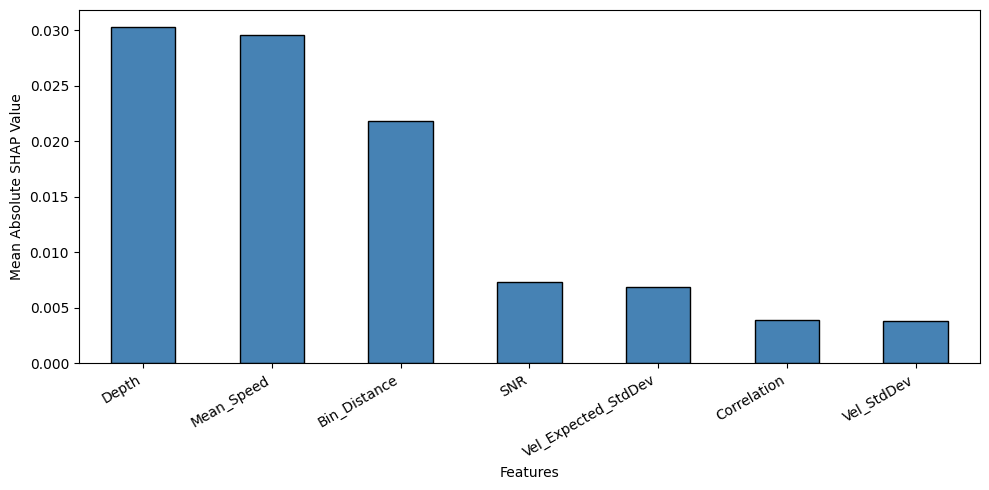

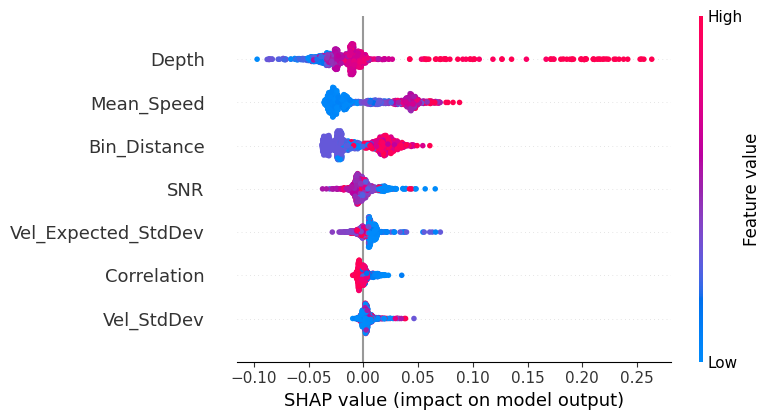


Mean |SHAP| per feature:
Depth                  0.030299
Mean_Speed             0.029555
Bin_Distance           0.021830
SNR                    0.007308
Vel_Expected_StdDev    0.006882
Correlation            0.003899
Vel_StdDev             0.003807


In [5]:
print('=== SHAP Analysis — RF on BT_Vel_stage1 (field main target) ===')

# Use RF trained on BT_Vel_stage1 from split
rf_model, X_tr_s, X_te_s, y_tr, y_te = trained_s1['Random Forest']

explainer = shap.TreeExplainer(rf_model)
shap_vals = explainer.shap_values(X_te_s)

# Global SHAP bar chart
mean_shap = np.abs(shap_vals).mean(axis=0)
shap_df   = pd.Series(mean_shap, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10,5))
shap_df.plot(kind='bar', color='steelblue', edgecolor='black')
#plt.title('SHAP Feature Importance — RF, Field (BT_Vel_stage1)')
plt.ylabel('Mean Absolute SHAP Value')
plt.xlabel('Features')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('field_shap_stage1.png', dpi=550)
plt.show()

# SHAP beeswarm
shap.summary_plot(shap_vals, X_te_s, feature_names=FEATURES, show=False)
#plt.title('SHAP Beeswarm — RF, Field (BT_Vel_stage1)')
plt.tight_layout()
plt.savefig('field_shap_beeswarm_stage1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMean |SHAP| per feature:')
print(shap_df.round(6).to_string())


---
###  Enhanced Interpretability
Permutation importance (all models), ALE, local SHAP, prediction intervals, and feature-set comparison. Main target: `BT_Vel_stage1`.

#### Permutation Importance (all models)

=== Permutation Importance (ALL models) ===
  Random Forest: top = Depth (ΔR²=0.6738)
  Gradient Boosting: top = Depth (ΔR²=0.3862)
  XGBoost: top = Depth (ΔR²=0.3391)
  LightGBM: top = Depth (ΔR²=0.5574)
  CatBoost: top = Mean_Speed (ΔR²=0.4399)
  OLS: top = Mean_Speed (ΔR²=0.7989)
  Ridge: top = Mean_Speed (ΔR²=0.7978)
  Lasso: top = Mean_Speed (ΔR²=0.7894)

✅ Permutation importance (mean ΔR² when feature shuffled):
                     Random Forest  Gradient Boosting  XGBoost  LightGBM  CatBoost     OLS   Ridge   Lasso    MEAN
Mean_Speed                  0.3066             0.3576   0.2484    0.3094    0.4399  0.7989  0.7978  0.7894  0.5060
Depth                       0.6738             0.3862   0.3391    0.5574    0.2426  0.0950  0.0951  0.0866  0.3095
Bin_Distance                0.2277             0.0661   0.2234    0.2140    0.1304 -0.0000 -0.0000  0.0000  0.1077
Vel_StdDev                  0.0468             0.0340   0.1035    0.0261    0.2629  0.0711  0.0709  0.0441  0.0824
Cor

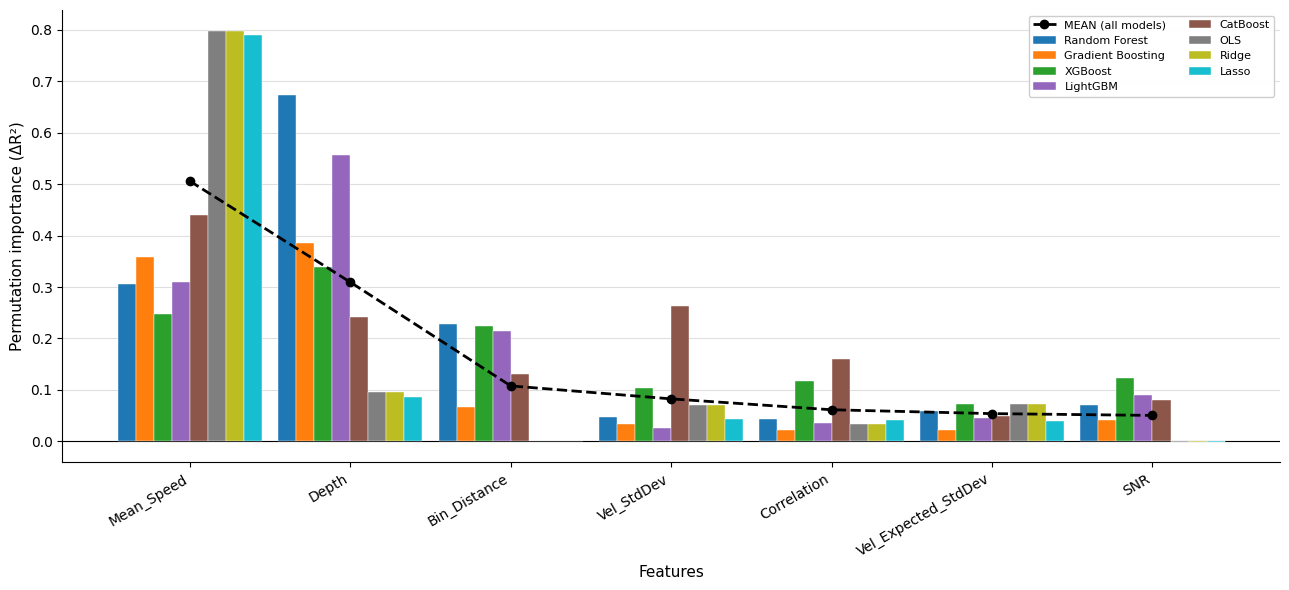

In [7]:
print('=== Permutation Importance (ALL models) ===')
# Model-agnostic. Cross-model agreement => feature relevance is a property of the
# task, not of any single model architecture .
from sklearn.inspection import permutation_importance

perm_results = {}
for name in ['Random Forest','Gradient Boosting','XGBoost','LightGBM','CatBoost',
             'OLS','Ridge','Lasso']:
    if name not in trained_s1:
        continue
    model, X_tr_s, X_te_s, y_tr, y_te = trained_s1[name]
    r = permutation_importance(model, X_te_s, y_te, n_repeats=20,
                               random_state=42, scoring='r2', n_jobs=-1)
    perm_results[name] = r.importances_mean
    print(f'  {name}: top = {FEATURES[r.importances_mean.argmax()]} '
          f'(ΔR²={r.importances_mean.max():.4f})')

perm_df = pd.DataFrame(perm_results, index=FEATURES)
perm_df['MEAN'] = perm_df.mean(axis=1)
perm_df = perm_df.sort_values('MEAN', ascending=False)

print('\n✅ Permutation importance (mean ΔR² when feature shuffled):')
print(perm_df.round(4).to_string())

# Grouped bar: each model + aggregate mean
fig, ax = plt.subplots(figsize=(13, 6))
plot_models = [c for c in perm_df.columns if c != 'MEAN']
x = np.arange(len(FEATURES)); w = 0.9 / len(plot_models)
cmap = plt.cm.tab10(np.linspace(0, 1, len(plot_models)))
order = perm_df.index.tolist()
for j, m in enumerate(plot_models):
    vals = [perm_df.loc[f, m] for f in order]
    ax.bar(x + j*w - 0.45 + w/2, vals, width=w, label=m, color=cmap[j],
           edgecolor='white', linewidth=0.3, zorder=3)
ax.plot(x, [perm_df.loc[f,'MEAN'] for f in order], 'k--o', lw=2,
        ms=6, label='MEAN (all models)', zorder=4)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Permutation importance (ΔR²)', fontsize=11)
ax.set_xlabel('Features', fontsize=11)
#ax.set_title('Permutation Importance across all ML models — Field\n'
             #'Cross-model agreement indicates task-level (not model-specific) feature relevance',
             #fontsize=12, fontweight='bold')
ax.axhline(0, color='black', lw=0.8); ax.legend(fontsize=8, ncol=2, framealpha=0.95)
ax.grid(axis='y', alpha=0.4, zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('field_permutation_importance.png', dpi=550, bbox_inches='tight', facecolor='white')
plt.show()


#### Accumulated Local Effects (ALE) — RF

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


===  Accumulated Local Effects (ALE) — RF ===


PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


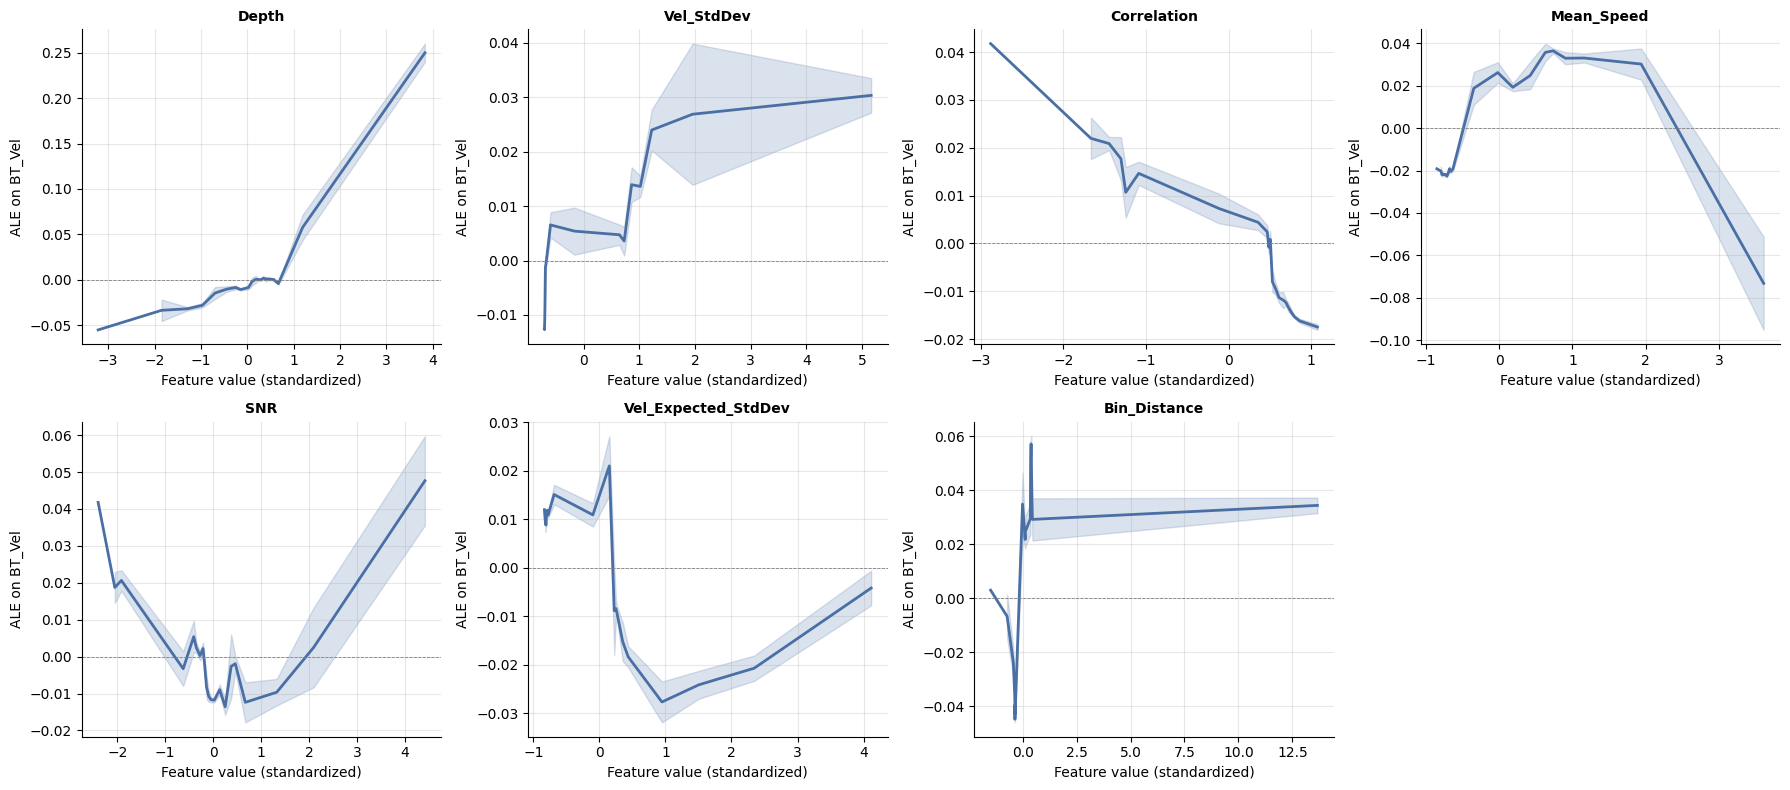

  ALE plots saved. Monotonic increasing ALE for Mean_Speed = physical (bedload up with flow).


In [8]:
print('===  Accumulated Local Effects (ALE) — RF ===')
# ALE shows the isolated marginal effect of each feature on the prediction,
# robust to feature correlation (unlike PDP). RF = best model.
try:
    from PyALE import ale
    HAS_PYALE = True
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable,'-m','pip','install','PyALE','-q','--break-system-packages'])
    try:
        from PyALE import ale; HAS_PYALE = True
    except Exception:
        HAS_PYALE = False
        print('  PyALE unavailable — using manual 1D ALE implementation')

rf_model, X_tr_s, X_te_s, y_tr, y_te = trained_s1['Random Forest']
X_te_df = pd.DataFrame(X_te_s, columns=FEATURES)

def manual_ale_1d(model, X, feat, bins=20):
    col = X[feat].values
    edges = np.quantile(col, np.linspace(0, 1, bins+1))
    edges = np.unique(edges)
    centers, eff = [], []
    for k in range(len(edges)-1):
        lo, hi = edges[k], edges[k+1]
        m = (col >= lo) & (col <= hi)
        if m.sum() < 2:
            continue
        Xl = X[m].copy(); Xu = X[m].copy()
        Xl[feat] = lo; Xu[feat] = hi
        delta = model.predict(Xu.values) - model.predict(Xl.values)
        centers.append((lo+hi)/2); eff.append(delta.mean())
    eff = np.cumsum(eff); eff = eff - eff.mean()   # centre
    return np.array(centers), eff

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for idx, feat in enumerate(FEATURES):
    ax = axes[idx]
    try:
        if HAS_PYALE:
            a = ale(X=X_te_df, model=rf_model, feature=[feat],
                    grid_size=20, include_CI=True, C=0.95, plot=False)
            xv = a.index.values; yv = a['eff'].values
            ax.plot(xv, yv, color='#4A6FA5', lw=2)
            if 'lowerCI_95%' in a.columns:
                ax.fill_between(xv, a['lowerCI_95%'], a['upperCI_95%'],
                                color='#4A6FA5', alpha=0.2)
        else:
            xv, yv = manual_ale_1d(rf_model, X_te_df, feat)
            ax.plot(xv, yv, color='#4A6FA5', lw=2)
    except Exception as e:
        xv, yv = manual_ale_1d(rf_model, X_te_df, feat)
        ax.plot(xv, yv, color='#4A6FA5', lw=2)
    ax.axhline(0, color='gray', lw=0.6, ls='--')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Feature value (standardized)', fontsize=10)
    ax.set_ylabel('ALE on BT_Vel', fontsize=10)
    ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for k in range(len(FEATURES), len(axes)):
    axes[k].axis('off')
#fig.suptitle('Accumulated Local Effects (ALE) — RF on BT_Vel_stage1 — Field',
             #fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('field_ALE_plots.png', dpi=550, bbox_inches='tight', facecolor='white')
plt.show()
print('  ALE plots saved. Monotonic increasing ALE for Mean_Speed = physical (bedload up with flow).')


#### Local SHAP — individual predictions (RF)

=== Local SHAP (waterfall) — RF, high vs low BT_Vel_stage1 ===


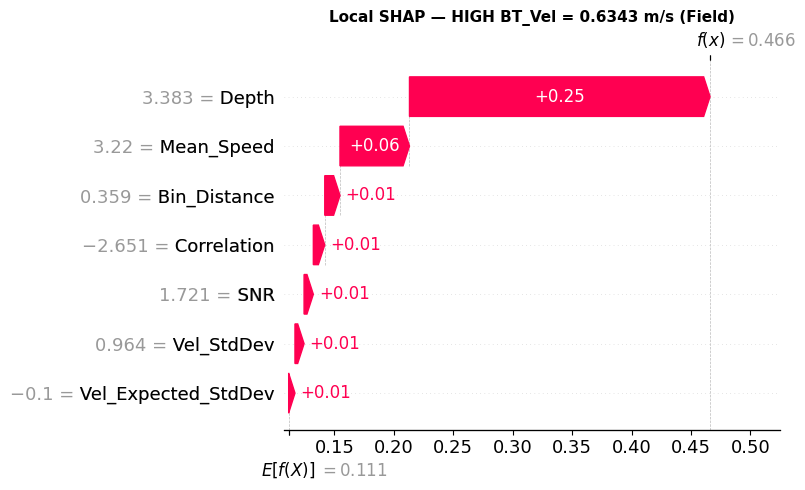


  HIGH prediction (true=0.6343, base=0.1115):
Depth                  0.25289
Mean_Speed             0.05846
Bin_Distance           0.01282
Correlation            0.00961
SNR                    0.00779
Vel_StdDev             0.00766
Vel_Expected_StdDev    0.00529


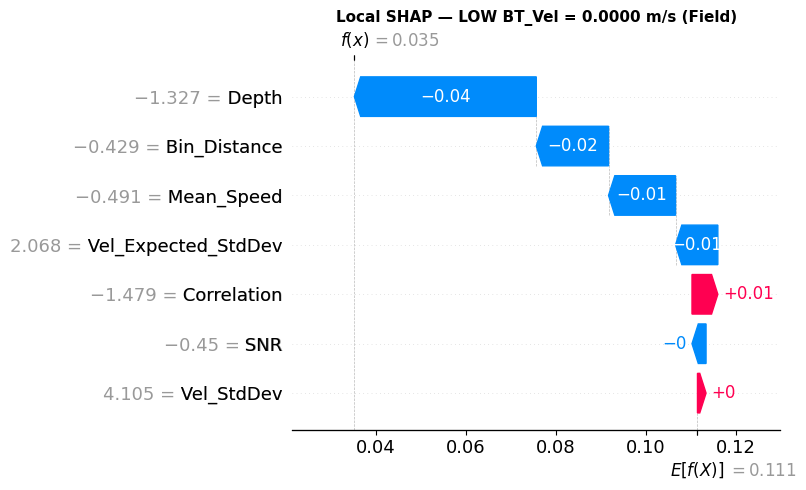


  LOW prediction (true=0.0000, base=0.1115):
Depth                 -0.04043
Bin_Distance          -0.01606
Mean_Speed            -0.01489
Vel_Expected_StdDev   -0.00941
Correlation            0.00575
SNR                   -0.00312
Vel_StdDev             0.00191


In [10]:
print('=== Local SHAP (waterfall) — RF, high vs low BT_Vel_stage1 ===')
# Explains two individual predictions: a high-transport and a low-transport ensemble.
import shap
rf_model, X_tr_s, X_te_s, y_tr, y_te = trained_s1['Random Forest']
explainer = shap.TreeExplainer(rf_model)

y_te_arr = np.asarray(y_te)
i_high = int(np.argmax(y_te_arr))   # strongest bed motion
i_low  = int(np.argmin(y_te_arr))   # near-stationary bed

sv_all = explainer.shap_values(X_te_s)
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = np.asarray(base_val).ravel()[0]

for label, i in [('HIGH', i_high), ('LOW', i_low)]:
    expl = shap.Explanation(values=sv_all[i], base_values=base_val,
                            data=X_te_s[i], feature_names=FEATURES)
    plt.figure()
    shap.plots.waterfall(expl, show=False, max_display=8)
    plt.title(f'Local SHAP — {label} BT_Vel = {y_te_arr[i]:.4f} m/s (Field)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'field_local_shap_{label.lower()}.png', dpi=550,
                bbox_inches='tight', facecolor='white')
    plt.show()
    contrib = pd.Series(sv_all[i], index=FEATURES).sort_values(key=np.abs, ascending=False)
    print(f'\n  {label} prediction (true={y_te_arr[i]:.4f}, base={base_val:.4f}):')
    print(contrib.round(5).to_string())


#### Prediction Intervals — Quantile RF

=== Prediction Intervals — Split-Conformal Quantile RF ===
  Conformal adjustment qhat = 0.01204 (widens raw band)
  Raw quantile-RF:   coverage 77.6%  width 0.0933 m/s
  Conformalized:     coverage 90.2%  width 0.1174 m/s  (target 90%)


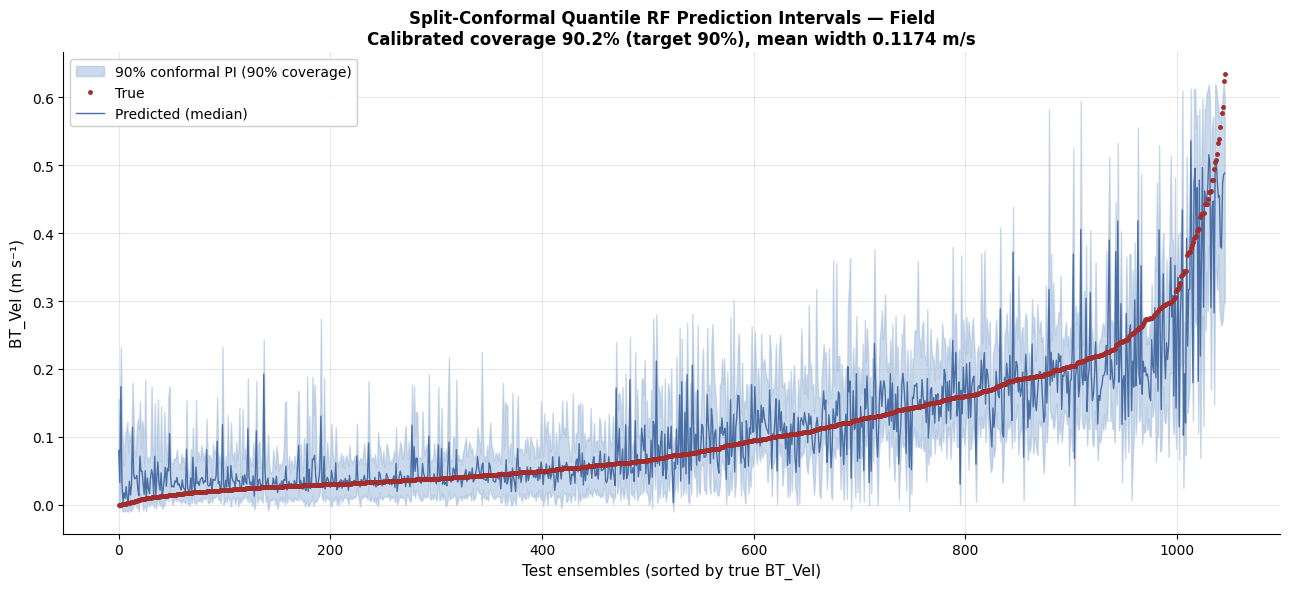

In [11]:
print('=== Prediction Intervals — Split-Conformal Quantile RF ===')
# Quantile RF gives raw 5th/95th percentiles, but these undercover because they
# capture only model spread. We calibrate with split-conformal adjustment on a
# held-out calibration set so empirical coverage matches the nominal 90%.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rf_model, X_tr_s, X_te_s, y_tr, y_te = trained_s1['Random Forest']
y_tr_arr = np.asarray(y_tr); y_te_arr = np.asarray(y_te)

# Split training data into proper-train + calibration (for conformal)
X_pt, X_cal, y_pt, y_cal = train_test_split(
    X_tr_s, y_tr_arr, test_size=0.3, random_state=42)

qrf = RandomForestRegressor(n_estimators=300, random_state=42,
                            min_samples_leaf=5, n_jobs=-1).fit(X_pt, y_pt)

def pi_bounds(model, X, lo_q=5, hi_q=95):
    per_tree = np.stack([t.predict(X) for t in model.estimators_], axis=0)
    return (np.percentile(per_tree, lo_q, axis=0),
            np.percentile(per_tree, 50, axis=0),
            np.percentile(per_tree, hi_q, axis=0))

# Raw bounds on calibration set → compute conformity scores
lo_cal, med_cal, hi_cal = pi_bounds(qrf, X_cal)
# conformity score: how far outside the raw band each cal point lies (CQR)
scores = np.maximum(lo_cal - y_cal, y_cal - hi_cal)
# 90% coverage → take the ceil((n+1)*0.9)/n quantile of scores
n_cal = len(y_cal)
q_level = np.ceil((n_cal + 1) * 0.90) / n_cal
q_level = min(q_level, 1.0)
qhat = np.quantile(scores, q_level)
print(f'  Conformal adjustment qhat = {qhat:.5f} (widens raw band)')

# Apply to test set
lo_t, med_t, hi_t = pi_bounds(qrf, X_te_s)
lo_adj = lo_t - qhat
hi_adj = hi_t + qhat

cov_raw = ((y_te_arr >= lo_t)  & (y_te_arr <= hi_t)).mean()
cov_adj = ((y_te_arr >= lo_adj) & (y_te_arr <= hi_adj)).mean()
w_raw   = (hi_t   - lo_t).mean()
w_adj   = (hi_adj - lo_adj).mean()

print(f'  Raw quantile-RF:   coverage {cov_raw*100:.1f}%  width {w_raw:.4f} m/s')
print(f'  Conformalized:     coverage {cov_adj*100:.1f}%  width {w_adj:.4f} m/s  (target 90%)')

# Plot conformalized intervals sorted by true value
order = np.argsort(y_te_arr); xx = np.arange(len(order))
fig, ax = plt.subplots(figsize=(13, 6))
ax.fill_between(xx, lo_adj[order], hi_adj[order], color='#A8C0DE', alpha=0.6,
                label=f'90% conformal PI ({cov_adj*100:.0f}% coverage)', zorder=2)
ax.plot(xx, y_te_arr[order], 'o', color='#A32D2D', ms=2.5, label='True', zorder=4)
ax.plot(xx, med_t[order], '-', color='#4A6FA5', lw=1, label='Predicted (median)', zorder=3)
ax.set_xlabel('Test ensembles (sorted by true BT_Vel)', fontsize=11)
ax.set_ylabel('BT_Vel (m s⁻¹)', fontsize=11)
ax.set_title(f'Split-Conformal Quantile RF Prediction Intervals — Field\n'
             f'Calibrated coverage {cov_adj*100:.1f}% (target 90%), mean width {w_adj:.4f} m/s',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('field_prediction_intervals.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


#### Feature Set Comparison 

=== RC1.5: Feature Set Comparison — DISJOINT groups ===
  P: Physical only         (6 feats)  CV R² = 0.7804 ± 0.0141
  S: ADCP settings only    (4 feats)  CV R² = 0.7354 ± 0.0137
  P+S: Combined            (10 feats)  CV R² = 0.8125 ± 0.0117

✅ Feature set comparison (RF, BT_Vel_stage1):
          Feature Set  N features  CV R²    Std  N rows
     P: Physical only           6 0.7804 0.0141    5230
S: ADCP settings only           4 0.7354 0.0137    5247
        P+S: Combined          10 0.8125 0.0117    5230

INTERPRETATION:
  Physical-only R²   = 0.780  (hydraulic signal)
  Settings-only R²   = 0.735  (instrument/geometry signal)
  Combined R²        = 0.812
  Physical − Settings gap = +0.045  (>0 => hydraulics dominate, NOT instrument artefacts)


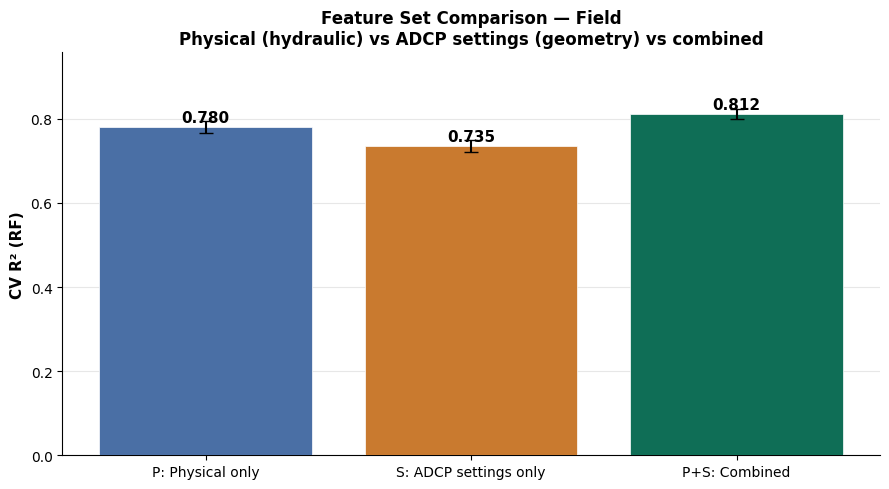

In [10]:
print('===  Feature Set Comparison — DISJOINT groups ===')
# contrast PHYSICAL/hydraulic features against ADCP
# SETTINGS/geometry features as SEPARATE groups (not nested), so the
# settings-only result is visible. Settings-alone giving low R² while
# physical-alone gives high R² => model learns hydraulics, not instrument

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.pipeline import make_pipeline

# Physical / hydraulic predictors
PHYSICAL = ['Mean_Speed','Depth','Vel_StdDev','Correlation','Vel_Expected_StdDev','SNR']
# ADCP settings / geometry predictors (bin size, blank distance, error velocity, range)
SETTINGS = [c for c in ['Bin_Distance','Cell_Size','Cell_Start','Error_Velocity']
            if c in df.columns]

feature_sets = {
    'P: Physical only':      PHYSICAL,
    'S: ADCP settings only': SETTINGS,
    'P+S: Combined':         PHYSICAL + SETTINGS,
}

def cv_r2_for(features, target_col):
    sub = df[features + [target_col]].dropna()
    Xf, yf = sub[features], sub[target_col]
    bins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
    yb   = bins.fit_transform(yf.values.reshape(-1,1)).ravel().astype(int)
    skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipe = make_pipeline(StandardScaler(),
                         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    scores = cross_val_score(pipe, Xf, yf, cv=skf.split(Xf, yb), scoring='r2')
    return scores.mean(), scores.std(), len(sub)

fs_rows = []
for sname, feats in feature_sets.items():
    m, s, n = cv_r2_for(feats, 'BT_Vel_stage1')
    fs_rows.append({'Feature Set': sname, 'N features': len(feats),
                    'Features': ', '.join(feats),
                    'CV R²': round(m,4), 'Std': round(s,4), 'N rows': n})
    print(f'  {sname:24s} ({len(feats)} feats)  CV R² = {m:.4f} ± {s:.4f}')

fs_df = pd.DataFrame(fs_rows)
print('\n✅ Feature set comparison (RF, BT_Vel_stage1):')
print(fs_df[['Feature Set','N features','CV R²','Std','N rows']].to_string(index=False))

# Interpretation line
r_phys = fs_rows[0]['CV R²']; r_set = fs_rows[1]['CV R²']; r_comb = fs_rows[2]['CV R²']
print(f'\nINTERPRETATION:')
print(f'  Physical-only R²   = {r_phys:.3f}  (hydraulic signal)')
print(f'  Settings-only R²   = {r_set:.3f}  (instrument/geometry signal)')
print(f'  Combined R²        = {r_comb:.3f}')
print(f'  Physical − Settings gap = {r_phys - r_set:+.3f}  '
      f'(>0 => hydraulics dominate, NOT instrument artefacts)')

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
cols = ['#4A6FA5','#C97A2F','#0F6E56']   # physical=blue, settings=orange, combined=green
bars = ax.bar(fs_df['Feature Set'], fs_df['CV R²'], yerr=fs_df['Std'],
              color=cols, capsize=5, edgecolor='white', linewidth=0.5, zorder=3)
for b, v in zip(bars, fs_df['CV R²']):
    ax.text(b.get_x()+b.get_width()/2, v+0.012, f'{v:.3f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('CV R² (RF)', fontsize=11, fontweight='bold')
ax.set_title('Feature Set Comparison — Field\n'
             'Physical (hydraulic) vs ADCP settings (geometry) vs combined',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(fs_df['CV R²'])*1.18)
ax.grid(axis='y', alpha=0.3, zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('field_feature_sets_disjoint.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


---
### Feature Correlation Heatmap — BT_Vel_stage1


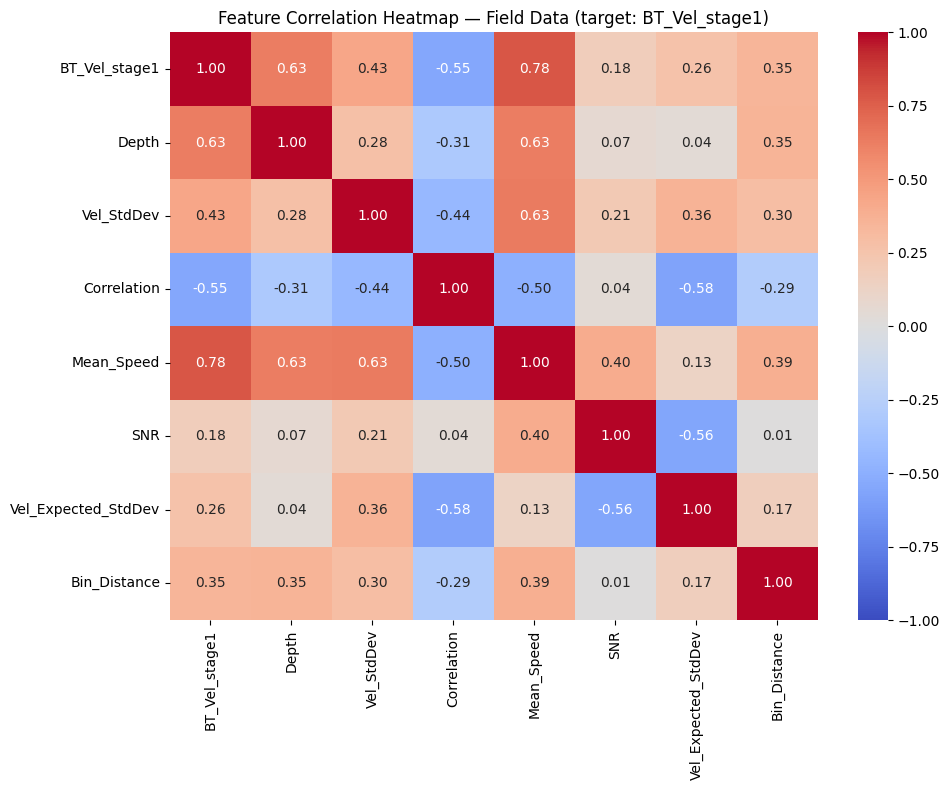


Correlation with BT_Vel_stage1:
BT_Vel_stage1          1.000
Mean_Speed             0.784
Depth                  0.626
Vel_StdDev             0.433
Bin_Distance           0.347
Vel_Expected_StdDev    0.260
SNR                    0.179
Correlation           -0.550
Name: BT_Vel_stage1, dtype: float64


In [11]:
# Correlation heatmap — BT_Vel_stage1 (main target)
heat_feats = ['BT_Vel_stage1'] + FEATURES
df_heat = df[heat_feats].dropna()

plt.figure(figsize=(10,8))
sns.heatmap(df_heat.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap — Field Data (target: BT_Vel_stage1)')
plt.tight_layout()
plt.savefig('field_correlation_stage1.png', dpi=150)
plt.show()

print('\nCorrelation with BT_Vel_stage1:')
print(df_heat.corr()['BT_Vel_stage1'].sort_values(ascending=False).round(3))
